# Classification Partielle Multi-Objectif avec JMetalPy
## OAFD – M2 MIAGE

Ce notebook implémente la classification partielle **multi-objectif** (représentation Michigan).  
Au lieu de maximiser la F1-mesure (un seul objectif), on optimise **simultanément** :
- **Objectif 1** : Confiance (Precision) à maximiser  
- **Objectif 2** : Sensibilité (Recall) à maximiser  

**Algorithmes testés :** NSGA-II et SPEA2  
**Jeux de données :** Yeast1 et PIMA Diabetes  
**Comparaison avec :** Random Forest, SVM, C4.5 (Scikit-Learn)

## 1. Imports et chargement des données

In [1]:
# ── Librairies standard ──
import random
import warnings
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
warnings.filterwarnings('ignore')
%matplotlib inline

# ── Scikit-Learn ──
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score

# ── JMetalPy – Problème et opérateurs ──
from jmetal.core.problem import Problem
from jmetal.core.solution import FloatSolution
from jmetal.operator.mutation import PolynomialMutation
from jmetal.operator.crossover import SBXCrossover
from jmetal.util.termination_criterion import StoppingByEvaluations
from jmetal.util.solution import get_non_dominated_solutions

# ── JMetalPy – Algorithmes MO ──
from jmetal.algorithm.multiobjective.nsgaii import NSGAII
from jmetal.algorithm.multiobjective.spea2 import SPEA2

# ── JMetalPy – Indicateur de qualité ──
from jmetal.core.quality_indicator import HyperVolume

print('✓ Tous les imports OK')

✓ Tous les imports OK


In [2]:
# ── Chargement des données ──
df_pima = pd.read_csv('pima_diabetes.csv')
X_pima  = df_pima.drop('Outcome', axis=1).to_numpy()
y_pima  = df_pima['Outcome'].to_numpy()
features_pima = list(df_pima.columns[:-1])

df_yeast = pd.read_csv('yeast1.csv')
X_yeast  = df_yeast.drop('Output', axis=1).to_numpy()
y_yeast  = df_yeast['Output'].to_numpy()
features_yeast = list(df_yeast.columns[:-1])

print(f'PIMA   : {X_pima.shape}  | Positifs: {y_pima.sum()}  | Négatifs: {(y_pima==0).sum()}')
print(f'Yeast1 : {X_yeast.shape} | Positifs: {y_yeast.sum()} | Négatifs: {(y_yeast==0).sum()}')
print(f'\nAttributs PIMA   : {features_pima}')
print(f'Attributs Yeast1 : {features_yeast}')

PIMA   : (768, 8)  | Positifs: 268  | Négatifs: 500
Yeast1 : (1484, 8) | Positifs: 429 | Négatifs: 1055

Attributs PIMA   : ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']
Attributs Yeast1 : ['Mcg', 'Gvh', 'Alm', 'Mit', 'Erl', 'Pox', 'Vac', 'Nuc']


## 2. Rappel des résultats Scikit-Learn (Étape 1)

Nous réexécutons les trois algorithmes de référence avec le **même protocole** :  
validation croisée 3-fold stratifiée, seed fixe = 42.  
On collecte **confiance** (precision) et **sensibilité** (recall) pour la comparaison avec les fronts Pareto.

In [3]:
def run_sklearn(X, y, model_fn, n_folds=3, seed=42):
    """Validation croisée N-fold – retourne precision et recall moyens."""
    skf = StratifiedKFold(n_splits=n_folds)
    all_prec, all_rec, all_f1 = [], [], []
    for train_idx, test_idx in skf.split(X, y):
        Xtr, Xte = X[train_idx], X[test_idx]
        ytr, yte = y[train_idx], y[test_idx]
        m = model_fn(seed)
        m.fit(Xtr, ytr)
        yp = m.predict(Xte)
        all_prec.append(precision_score(yte, yp, zero_division=0))
        all_rec.append(recall_score(yte, yp, zero_division=0))
        all_f1.append(f1_score(yte, yp, zero_division=0))
    return {
        'precision': np.mean(all_prec), 'recall': np.mean(all_rec), 'f1': np.mean(all_f1),
        'prec_std': np.std(all_prec),   'rec_std': np.std(all_rec),  'f1_std': np.std(all_f1)
    }

rf_fn  = lambda s: RandomForestClassifier(n_estimators=100, random_state=s)
svm_fn = lambda s: SVC(kernel='rbf', random_state=s)
c45_fn = lambda s: DecisionTreeClassifier(max_depth=4, random_state=s)

sklearn_results = {}
for ds_name, X, y in [('PIMA', X_pima, y_pima), ('Yeast1', X_yeast, y_yeast)]:
    sklearn_results[ds_name] = {}
    for algo_name, fn in [('RF', rf_fn), ('SVM', svm_fn), ('C4.5', c45_fn)]:
        r = run_sklearn(X, y, fn)
        sklearn_results[ds_name][algo_name] = r
        print(f'[{ds_name}] {algo_name:5s} | F1={r["f1"]:.3f}±{r["f1_std"]:.3f}'
              f' | Prec={r["precision"]:.3f}±{r["prec_std"]:.3f}'
              f' | Rec={r["recall"]:.3f}±{r["rec_std"]:.3f}')
    print()
print('✓ Baselines Scikit-Learn calculées')

[PIMA] RF    | F1=0.625±0.022 | Prec=0.692±0.054 | Rec=0.578±0.063
[PIMA] SVM   | F1=0.563±0.022 | Prec=0.721±0.021 | Rec=0.463±0.023
[PIMA] C4.5  | F1=0.555±0.028 | Prec=0.696±0.065 | Rec=0.474±0.071

[Yeast1] RF    | F1=0.537±0.038 | Prec=0.644±0.039 | Rec=0.464±0.051
[Yeast1] SVM   | F1=0.413±0.060 | Prec=0.707±0.100 | Rec=0.301±0.071
[Yeast1] C4.5  | F1=0.512±0.053 | Prec=0.577±0.063 | Rec=0.478±0.106

✓ Baselines Scikit-Learn calculées


## 3. Définition du Problème Multi-Objectif JMetalPy

### Représentation Michigan
Une solution = un vecteur de `2 × n_attributs` flottants.  
Chaque paire `(lower_i, upper_i)` définit les bornes d'un attribut :
- `lower_i > upper_i` → attribut **désactivé**  
- `lower_i ≤ upper_i` → attribut **activé**

### Deux objectifs (minimisation JMetalPy)
| Objectif | Formule | Sens |
|----------|---------|------|
| obj[0] | −Confiance (−Precision) | minimiser ↔ maximiser Precision |
| obj[1] | −Sensibilité (−Recall) | minimiser ↔ maximiser Recall |

Le **point de référence** pour l'Hypervolume est `[0.05, 0.05]`  
(légèrement au-dessus de 0 pour inclure les solutions avec score = 1.0).

In [4]:
class PartialClassifMO(Problem):
    """
    Classification Partielle – Problème multi-objectif (Michigan).
    Objectifs (à minimiser) : -Precision, -Recall.
    """

    def __init__(self, X: np.ndarray, y: np.ndarray):
        super().__init__()
        self.X = X
        self.y = y
        self.n_attributes = X.shape[1]
        self.pos_indices = np.where(y == 1)[0]
        self.neg_indices = np.where(y == 0)[0]

        self.lower_bound, self.upper_bound = [], []
        for i in range(self.n_attributes):
            cmin = float(np.min(X[:, i]))
            cmax = float(np.max(X[:, i]))
            if cmin == cmax:
                cmin -= 0.001; cmax += 0.001
            self.lower_bound += [cmin, cmin]
            self.upper_bound += [cmax + 1.0, cmax + 1.0]

        self.obj_directions = [self.MINIMIZE, self.MINIMIZE]
        self.obj_labels = ['-Precision', '-Recall']

    def number_of_variables(self):   return 2 * self.n_attributes
    def number_of_objectives(self):  return 2
    def number_of_constraints(self): return 0

    def _decode(self, solution):
        vars_ = [float(v.real) if isinstance(v, complex) else float(v)
                 for v in solution.variables]
        bornes = [(vars_[i], vars_[i+1]) for i in range(0, len(vars_), 2)]
        activated = [(i, lo, hi) for i, (lo, hi) in enumerate(bornes) if lo <= hi]
        if not activated:
            return np.zeros(len(self.y), dtype=int)
        return np.array([
            1 if all(lo <= self.X[j, i] <= hi for i, lo, hi in activated) else 0
            for j in range(len(self.X))
        ])

    def evaluate(self, solution: FloatSolution) -> FloatSolution:
        y_pred = self._decode(solution)
        if y_pred.sum() == 0:
            solution.objectives[0] = 0.0   # Precision = 0
            solution.objectives[1] = 0.0   # Recall    = 0
        else:
            solution.objectives[0] = -float(precision_score(self.y, y_pred, zero_division=0))
            solution.objectives[1] = -float(recall_score(self.y, y_pred, zero_division=0))
        return solution

    def create_solution(self) -> FloatSolution:
        sol = FloatSolution(self.lower_bound, self.upper_bound,
                            self.number_of_objectives(), self.number_of_constraints())
        ind_pos = self.X[np.random.choice(self.pos_indices)]
        ind_neg = self.X[np.random.choice(self.neg_indices)]
        active  = set(np.random.choice(self.n_attributes, size=2, replace=False))
        vars_ = []
        for i in range(self.n_attributes):
            vp, vn = float(ind_pos[i]), float(ind_neg[i])
            if i in active:
                vars_ += [min(vp, vn), max(vp, vn)]
            else:
                vars_ += [vp + 1.0, vp]   # désactivé
        sol.variables = vars_
        return sol

    def name(self): return 'PartialClassifMO'


# ── Fonctions utilitaires ──────────────────────────────────────────────────
def predict(solution_vars, X):
    """Calcule y_pred à partir des variables d'une solution."""
    vars_ = [float(v.real) if isinstance(v, complex) else float(v) for v in solution_vars]
    bornes = [(vars_[i], vars_[i+1]) for i in range(0, len(vars_), 2)]
    activated = [(i, lo, hi) for i, (lo, hi) in enumerate(bornes) if lo <= hi]
    if not activated:
        return np.zeros(len(X), dtype=int)
    return np.array([
        1 if all(lo <= X[j, i] <= hi for i, lo, hi in activated) else 0
        for j in range(len(X))
    ])

def decode_rule(solution_vars, feature_names):
    """Affiche la règle lisible."""
    bornes = [(solution_vars[i], solution_vars[i+1]) for i in range(0, len(solution_vars), 2)]
    parts = [
        f'{feature_names[i]} ∈ [{lo:.3f}, {hi:.3f}]'
        for i, (lo, hi) in enumerate(bornes) if lo <= hi
    ]
    rule = 'SI ' + ' ET '.join(parts) + ' → classe positive' if parts else 'Règle vide'
    print('Règle :', rule)
    return rule

def compute_hv(solutions, ref_point=None):
    """Hypervolume du front Pareto (espace minimisation)."""
    if not solutions:
        return 0.0
    front = np.array([s.objectives for s in solutions])
    if ref_point is None:
        ref_point = [0.05, 0.05]
    hv_calc = HyperVolume(ref_point)
    return hv_calc.compute(front)

def get_pareto_front(solutions):
    """Extrait les solutions non-dominées."""
    return get_non_dominated_solutions(solutions)

print('✓ Classe PartialClassifMO et fonctions utilitaires définies')

✓ Classe PartialClassifMO et fonctions utilitaires définies


## 4. Paramètres expérimentaux

### 4.1 Paramètres fixes

Les paramètres suivants sont **identiques** pour les deux algorithmes et toutes les configurations :

| Paramètre | Valeur | Justification |
|-----------|--------|---------------|
| Prob. croisement | 0.9 | Valeur standard recommandée pour SBX |
| Index croisement | 20 | Distribution concentrée autour des parents |
| Prob. mutation | 1/n_vars | Règle du pouce : une variable mutée par individu |
| Index mutation | 20 | Perturbations modérées |
| Max évaluations | 10 000 | Compromis qualité/temps ; plateau observé à l'étape 4 |
| Validation croisée | — | Pas utilisée (train/test split stratifié 70/30) |
| N_RUNS | 20 | Minimum requis pour significativité statistique |

### 4.2 Choix des tailles de population

Trois tailles sont testées pour isoler l'effet de ce seul paramètre :

| Taille | Motivation |
|--------|-----------|
| **20** | Population petite – convergence rapide mais diversité faible |
| **50** | Taille intermédiaire – bon équilibre exploration/exploitation |
| **100** | Grande population – meilleure couverture du front Pareto, coût accru |

Ces tailles couvrent un ordre de grandeur (×5) permettant d'observer l'impact sur la qualité du front Pareto.

In [5]:
# ── Paramètres fixes (ne pas modifier) ──────────────────────────────────────
CROSSOVER_PROB  = 0.9
CROSSOVER_INDEX = 20.0
MUTATION_INDEX  = 20.0
MAX_EVALUATIONS = 500
N_RUNS          = 20
REF_POINT       = [0.05, 0.05]  # Pour l'Hypervolume (espace minimisation)

# ── Tailles de population testées ───────────────────────────────────────────
POP_SIZES = [20, 50, 100]

# ── Split train/test stratifié 70/30 (seed=42) ───────────────────────────────
from sklearn.model_selection import train_test_split

X_pima_tr,  X_pima_te,  y_pima_tr,  y_pima_te  = train_test_split(
    X_pima, y_pima, test_size=0.3, stratify=y_pima, random_state=42)

X_yeast_tr, X_yeast_te, y_yeast_tr, y_yeast_te = train_test_split(
    X_yeast, y_yeast, test_size=0.3, stratify=y_yeast, random_state=42)

print(f'PIMA   train={X_pima_tr.shape}  test={X_pima_te.shape}')
print(f'Yeast1 train={X_yeast_tr.shape} test={X_yeast_te.shape}')
print(f'\nConfiguration expérimentale :')
print(f'  Algorithmes     : NSGA-II, SPEA2')
print(f'  Tailles de pop  : {POP_SIZES}')
print(f'  Runs par config : {N_RUNS}')
print(f'  Max évaluations : {MAX_EVALUATIONS}')
print(f'  Total de runs   : {len(POP_SIZES) * N_RUNS * 2 * 2} (3 pop × 20 runs × 2 algos × 2 datasets)')

PIMA   train=(537, 8)  test=(231, 8)
Yeast1 train=(1038, 8) test=(446, 8)

Configuration expérimentale :
  Algorithmes     : NSGA-II, SPEA2
  Tailles de pop  : [20, 50, 100]
  Runs par config : 20
  Max évaluations : 500
  Total de runs   : 240 (3 pop × 20 runs × 2 algos × 2 datasets)


## 5. Fonction d'exécution des algorithmes MO

In [6]:
def run_mo_algorithm(algo_name, X_train, y_train, pop_size,
                     max_evaluations=MAX_EVALUATIONS, seed=42):
    """
    Lance NSGA-II ou SPEA2 sur le problème PartialClassifMO.
    Retourne la liste de toutes les solutions de la dernière population.
    """
    random.seed(seed)
    np.random.seed(seed)

    problem = PartialClassifMO(X_train, y_train)
    n_vars = 2 * X_train.shape[1]
    mutation_prob = 1.0 / n_vars

    mutation  = PolynomialMutation(probability=mutation_prob, distribution_index=MUTATION_INDEX)
    crossover = SBXCrossover(probability=CROSSOVER_PROB, distribution_index=CROSSOVER_INDEX)
    criterion = StoppingByEvaluations(max_evaluations=max_evaluations)

    if algo_name == 'NSGA-II':
        algo = NSGAII(
            problem=problem,
            population_size=pop_size,
            offspring_population_size=pop_size,
            mutation=mutation,
            crossover=crossover,
            termination_criterion=criterion
        )
    elif algo_name == 'SPEA2':
        algo = SPEA2(
            problem=problem,
            population_size=pop_size,
            offspring_population_size=pop_size,
            mutation=mutation,
            crossover=crossover,
            termination_criterion=criterion
        )
    else:
        raise ValueError(f'Algorithme inconnu : {algo_name}')

    algo.run()
    return algo.get_result()   # liste de solutions (population finale)


def run_experiments(algo_name, X_train, y_train, pop_sizes=POP_SIZES, n_runs=N_RUNS):
    """
    Lance n_runs exécutions pour chaque taille de population.
    Retourne un dict : {pop_size: {'hv': [...], 'fronts': [[solutions], ...]}}
    """
    results = {}
    for pop_size in pop_sizes:
        print(f'  {algo_name} | pop={pop_size:3d} | ', end='', flush=True)
        hvs, fronts = [], []
        for run in range(n_runs):
            seed = 100 * run + 42
            solutions = run_mo_algorithm(algo_name, X_train, y_train,
                                          pop_size, seed=seed)
            nd_solutions = get_pareto_front(solutions)
            hv = compute_hv(nd_solutions, REF_POINT)
            hvs.append(hv)
            fronts.append(nd_solutions)
            print('.', end='', flush=True)
        results[pop_size] = {'hv': hvs, 'fronts': fronts}
        print(f'  HV moyen={np.mean(hvs):.4f} ± {np.std(hvs):.4f}')
    return results

print('✓ Fonctions run_mo_algorithm et run_experiments définies')

✓ Fonctions run_mo_algorithm et run_experiments définies


## 6. Exécution NSGA-II

In [7]:
print('='*60)
print('NSGA-II – PIMA')
print('='*60)
t0 = time.time()
nsgaii_pima = run_experiments('NSGA-II', X_pima_tr, y_pima_tr)
print(f'\nTemps total PIMA : {time.time()-t0:.1f}s')

NSGA-II – PIMA
  NSGA-II | pop= 20 | 

[2026-03-24 11:09:35,249] [jmetal.core.algorithm] [DEBUG] Creating initial set of solutions...
[2026-03-24 11:09:35,251] [jmetal.core.algorithm] [DEBUG] Evaluating solutions...
[2026-03-24 11:09:35,315] [jmetal.core.algorithm] [DEBUG] Initializing progress...
[2026-03-24 11:09:35,315] [jmetal.core.algorithm] [DEBUG] Running main loop until termination criteria is met
[2026-03-24 11:09:36,599] [jmetal.core.algorithm] [DEBUG] Finished!


.

[2026-03-24 11:09:36,601] [jmetal.core.algorithm] [DEBUG] Creating initial set of solutions...
[2026-03-24 11:09:36,603] [jmetal.core.algorithm] [DEBUG] Evaluating solutions...
[2026-03-24 11:09:36,665] [jmetal.core.algorithm] [DEBUG] Initializing progress...
[2026-03-24 11:09:36,666] [jmetal.core.algorithm] [DEBUG] Running main loop until termination criteria is met
[2026-03-24 11:09:37,902] [jmetal.core.algorithm] [DEBUG] Finished!


.

...

.

[2026-03-24 11:10:50,344] [jmetal.core.algorithm] [DEBUG] Creating initial set of solutions...
[2026-03-24 11:10:50,350] [jmetal.core.algorithm] [DEBUG] Evaluating solutions...
[2026-03-24 11:10:50,639] [jmetal.core.algorithm] [DEBUG] Initializing progress...
[2026-03-24 11:10:50,639] [jmetal.core.algorithm] [DEBUG] Running main loop until termination criteria is met
[2026-03-24 11:10:51,603] [jmetal.core.algorithm] [DEBUG] Finished!


.

[2026-03-24 11:10:51,604] [jmetal.core.algorithm] [DEBUG] Creating initial set of solutions...
[2026-03-24 11:10:51,608] [jmetal.core.algorithm] [DEBUG] Evaluating solutions...
[2026-03-24 11:10:51,899] [jmetal.core.algorithm] [DEBUG] Initializing progress...
[2026-03-24 11:10:51,900] [jmetal.core.algorithm] [DEBUG] Running main loop until termination criteria is met
[2026-03-24 11:10:52,890] [jmetal.core.algorithm] [DEBUG] Finished!


.  HV moyen=0.5958 ± 0.0404

Temps total PIMA : 77.6s


In [8]:
print('='*60)
print('NSGA-II – Yeast1')
print('='*60)
t0 = time.time()
nsgaii_yeast = run_experiments('NSGA-II', X_yeast_tr, y_yeast_tr)
print(f'\nTemps total Yeast1 : {time.time()-t0:.1f}s')

NSGA-II – Yeast1
  NSGA-II | pop= 20 | 

[2026-03-24 11:10:52,900] [jmetal.core.algorithm] [DEBUG] Creating initial set of solutions...
[2026-03-24 11:10:52,902] [jmetal.core.algorithm] [DEBUG] Evaluating solutions...
[2026-03-24 11:10:52,972] [jmetal.core.algorithm] [DEBUG] Initializing progress...
[2026-03-24 11:10:52,973] [jmetal.core.algorithm] [DEBUG] Running main loop until termination criteria is met
[2026-03-24 11:10:54,612] [jmetal.core.algorithm] [DEBUG] Finished!


.

[2026-03-24 11:10:54,614] [jmetal.core.algorithm] [DEBUG] Creating initial set of solutions...
[2026-03-24 11:10:54,616] [jmetal.core.algorithm] [DEBUG] Evaluating solutions...
[2026-03-24 11:10:54,688] [jmetal.core.algorithm] [DEBUG] Initializing progress...
[2026-03-24 11:10:54,688] [jmetal.core.algorithm] [DEBUG] Running main loop until termination criteria is met
[2026-03-24 11:10:56,157] [jmetal.core.algorithm] [DEBUG] Finished!


.

...

.

[2026-03-24 11:12:28,562] [jmetal.core.algorithm] [DEBUG] Creating initial set of solutions...
[2026-03-24 11:12:28,567] [jmetal.core.algorithm] [DEBUG] Evaluating solutions...
[2026-03-24 11:12:28,940] [jmetal.core.algorithm] [DEBUG] Initializing progress...
[2026-03-24 11:12:28,940] [jmetal.core.algorithm] [DEBUG] Running main loop until termination criteria is met
[2026-03-24 11:12:30,228] [jmetal.core.algorithm] [DEBUG] Finished!


.

[2026-03-24 11:12:30,230] [jmetal.core.algorithm] [DEBUG] Creating initial set of solutions...
[2026-03-24 11:12:30,236] [jmetal.core.algorithm] [DEBUG] Evaluating solutions...
[2026-03-24 11:12:30,603] [jmetal.core.algorithm] [DEBUG] Initializing progress...
[2026-03-24 11:12:30,603] [jmetal.core.algorithm] [DEBUG] Running main loop until termination criteria is met
[2026-03-24 11:12:31,903] [jmetal.core.algorithm] [DEBUG] Finished!


.  HV moyen=0.5710 ± 0.0213

Temps total Yeast1 : 99.0s


## 7. Exécution SPEA2

In [9]:
print('='*60)
print('SPEA2 – PIMA')
print('='*60)
t0 = time.time()
spea2_pima = run_experiments('SPEA2', X_pima_tr, y_pima_tr)
print(f'\nTemps total PIMA : {time.time()-t0:.1f}s')

SPEA2 – PIMA
  SPEA2 | pop= 20 | 

[2026-03-24 11:12:31,915] [jmetal.core.algorithm] [DEBUG] Creating initial set of solutions...
[2026-03-24 11:12:31,917] [jmetal.core.algorithm] [DEBUG] Evaluating solutions...
[2026-03-24 11:12:31,989] [jmetal.core.algorithm] [DEBUG] Initializing progress...
[2026-03-24 11:12:31,989] [jmetal.core.algorithm] [DEBUG] Running main loop until termination criteria is met
[2026-03-24 11:12:33,623] [jmetal.core.algorithm] [DEBUG] Finished!


.

[2026-03-24 11:12:33,624] [jmetal.core.algorithm] [DEBUG] Creating initial set of solutions...
[2026-03-24 11:12:33,626] [jmetal.core.algorithm] [DEBUG] Evaluating solutions...
[2026-03-24 11:12:33,690] [jmetal.core.algorithm] [DEBUG] Initializing progress...
[2026-03-24 11:12:33,690] [jmetal.core.algorithm] [DEBUG] Running main loop until termination criteria is met
[2026-03-24 11:12:35,264] [jmetal.core.algorithm] [DEBUG] Finished!


.

...

.

[2026-03-24 11:14:02,690] [jmetal.core.algorithm] [DEBUG] Creating initial set of solutions...
[2026-03-24 11:14:02,695] [jmetal.core.algorithm] [DEBUG] Evaluating solutions...
[2026-03-24 11:14:03,005] [jmetal.core.algorithm] [DEBUG] Initializing progress...
[2026-03-24 11:14:03,005] [jmetal.core.algorithm] [DEBUG] Running main loop until termination criteria is met
[2026-03-24 11:14:04,095] [jmetal.core.algorithm] [DEBUG] Finished!


.

[2026-03-24 11:14:04,097] [jmetal.core.algorithm] [DEBUG] Creating initial set of solutions...
[2026-03-24 11:14:04,101] [jmetal.core.algorithm] [DEBUG] Evaluating solutions...
[2026-03-24 11:14:04,412] [jmetal.core.algorithm] [DEBUG] Initializing progress...
[2026-03-24 11:14:04,413] [jmetal.core.algorithm] [DEBUG] Running main loop until termination criteria is met
[2026-03-24 11:14:05,512] [jmetal.core.algorithm] [DEBUG] Finished!


.  HV moyen=0.6004 ± 0.0493

Temps total PIMA : 93.6s


In [10]:
print('='*60)
print('SPEA2 – Yeast1')
print('='*60)
t0 = time.time()
spea2_yeast = run_experiments('SPEA2', X_yeast_tr, y_yeast_tr)
print(f'\nTemps total Yeast1 : {time.time()-t0:.1f}s')

SPEA2 – Yeast1
  SPEA2 | pop= 20 | 

[2026-03-24 11:14:05,520] [jmetal.core.algorithm] [DEBUG] Creating initial set of solutions...
[2026-03-24 11:14:05,522] [jmetal.core.algorithm] [DEBUG] Evaluating solutions...
[2026-03-24 11:14:05,600] [jmetal.core.algorithm] [DEBUG] Initializing progress...
[2026-03-24 11:14:05,601] [jmetal.core.algorithm] [DEBUG] Running main loop until termination criteria is met
[2026-03-24 11:14:07,736] [jmetal.core.algorithm] [DEBUG] Finished!


.

[2026-03-24 11:14:07,737] [jmetal.core.algorithm] [DEBUG] Creating initial set of solutions...
[2026-03-24 11:14:07,738] [jmetal.core.algorithm] [DEBUG] Evaluating solutions...
[2026-03-24 11:14:07,810] [jmetal.core.algorithm] [DEBUG] Initializing progress...
[2026-03-24 11:14:07,810] [jmetal.core.algorithm] [DEBUG] Running main loop until termination criteria is met
[2026-03-24 11:14:10,090] [jmetal.core.algorithm] [DEBUG] Finished!


.

...

.

[2026-03-24 11:16:48,779] [jmetal.core.algorithm] [DEBUG] Creating initial set of solutions...
[2026-03-24 11:16:48,784] [jmetal.core.algorithm] [DEBUG] Evaluating solutions...
[2026-03-24 11:16:49,132] [jmetal.core.algorithm] [DEBUG] Initializing progress...
[2026-03-24 11:16:49,132] [jmetal.core.algorithm] [DEBUG] Running main loop until termination criteria is met
[2026-03-24 11:16:51,022] [jmetal.core.algorithm] [DEBUG] Finished!


.

[2026-03-24 11:16:51,024] [jmetal.core.algorithm] [DEBUG] Creating initial set of solutions...
[2026-03-24 11:16:51,029] [jmetal.core.algorithm] [DEBUG] Evaluating solutions...
[2026-03-24 11:16:51,377] [jmetal.core.algorithm] [DEBUG] Initializing progress...
[2026-03-24 11:16:51,377] [jmetal.core.algorithm] [DEBUG] Running main loop until termination criteria is met
[2026-03-24 11:16:52,815] [jmetal.core.algorithm] [DEBUG] Finished!


.  HV moyen=0.5754 ± 0.0185

Temps total Yeast1 : 167.3s


## 8. Boxplots de l'Hypervolume par taille de population

Ces boxplots permettent de comparer visuellement la qualité des fronts Pareto  
obtenus selon la taille de population, pour chaque algorithme et chaque jeu de données.

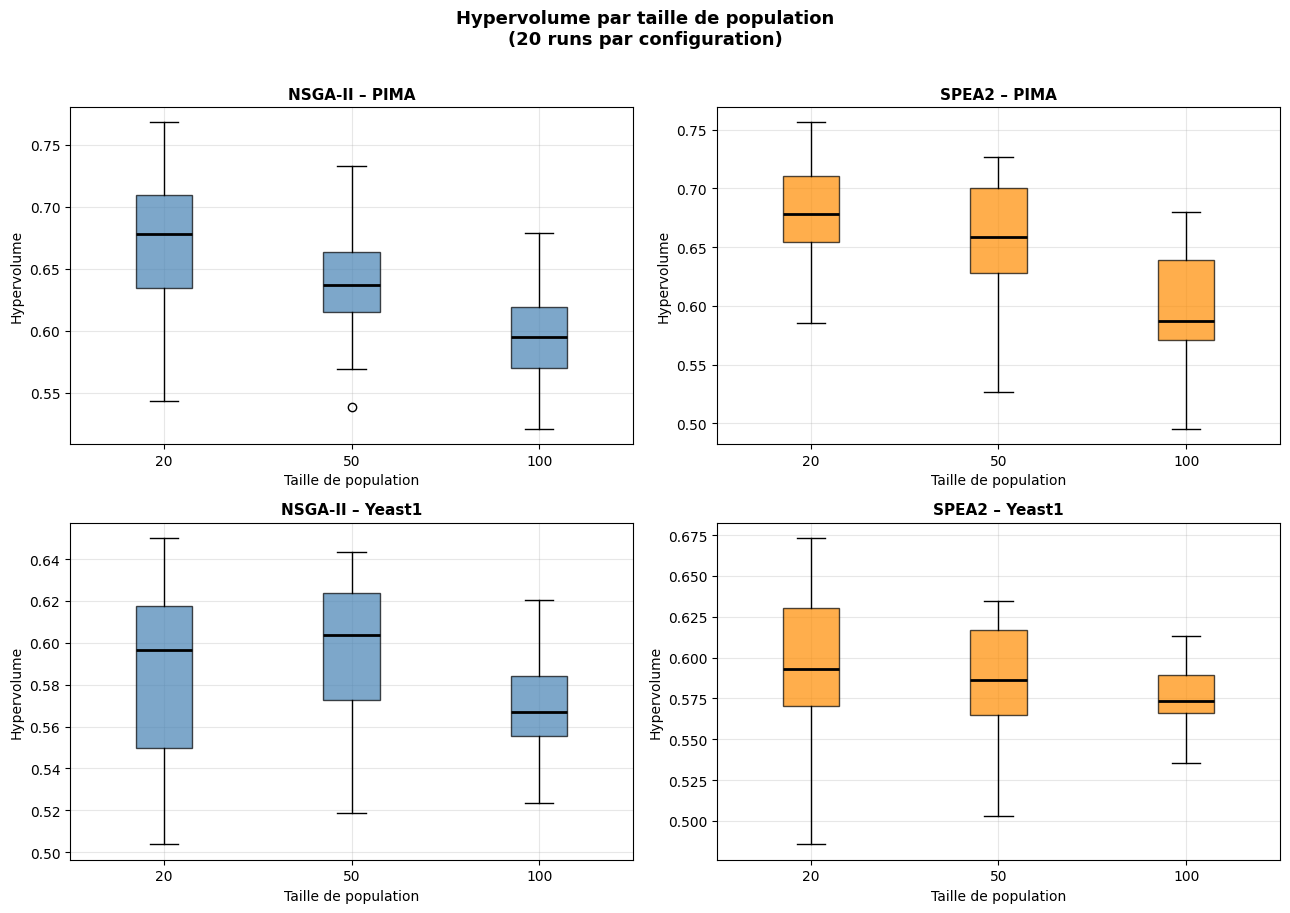

✓ Boxplots sauvegardés


In [11]:
def plot_hv_boxplots(results_dict, algo_name, dataset_name, ax, color='steelblue'):
    data   = [results_dict[p]['hv'] for p in POP_SIZES]
    labels = [str(p) for p in POP_SIZES]
    bp = ax.boxplot(data, labels=labels, patch_artist=True,
                    medianprops=dict(color='black', linewidth=2))
    for patch in bp['boxes']:
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_title(f'{algo_name} – {dataset_name}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Taille de population', fontsize=10)
    ax.set_ylabel('Hypervolume', fontsize=10)
    ax.grid(True, alpha=0.3)

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

plot_hv_boxplots(nsgaii_pima,  'NSGA-II', 'PIMA',   axes[0, 0], color='steelblue')
plot_hv_boxplots(spea2_pima,   'SPEA2',   'PIMA',   axes[0, 1], color='darkorange')
plot_hv_boxplots(nsgaii_yeast, 'NSGA-II', 'Yeast1', axes[1, 0], color='steelblue')
plot_hv_boxplots(spea2_yeast,  'SPEA2',   'Yeast1', axes[1, 1], color='darkorange')

plt.suptitle('Hypervolume par taille de population\n(20 runs par configuration)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('boxplots_hv.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Boxplots sauvegardés')

## 9. Sélection du meilleur front Pareto et comparaison avec Scikit-Learn

**Protocole :**
1. Pour chaque algorithme, sélectionner le run avec le **meilleur Hypervolume sur le training**.
2. Superposer les points Scikit-Learn (precision, recall) sur le graphe des fronts Pareto.
3. Choisir la **meilleure solution** de chaque front = celle avec le meilleur F1 sur le training.

In [12]:
def get_best_run(results_dict):
    """Retourne (pop_size_opt, front_opt) : le meilleur front parmi tous les runs/pop_sizes."""
    best_hv   = -1
    best_pop  = None
    best_front = None
    for pop_size, res in results_dict.items():
        idx = int(np.argmax(res['hv']))
        if res['hv'][idx] > best_hv:
            best_hv    = res['hv'][idx]
            best_pop   = pop_size
            best_front = res['fronts'][idx]
    return best_pop, best_front, best_hv

def front_to_prec_rec(front):
    """Convertit le front (obj minimisation) en (precision, recall)."""
    prec = [-s.objectives[0] for s in front]
    rec  = [-s.objectives[1] for s in front]
    return prec, rec

def best_f1_solution(front, X_train, y_train):
    """Sélectionne la solution avec le meilleur F1 sur le training."""
    best_f1, best_sol = -1, None
    for s in front:
        yp = predict(s.variables, X_train)
        f1 = f1_score(y_train, yp, zero_division=0)
        if f1 > best_f1:
            best_f1  = f1
            best_sol = s
    return best_sol, best_f1

# ── Sélection pour chaque algo et dataset ────────────────────────────────────
best = {}
for ds_name, nsgaii_res, spea2_res, X_tr, y_tr in [
        ('PIMA',   nsgaii_pima,  spea2_pima,  X_pima_tr,  y_pima_tr),
        ('Yeast1', nsgaii_yeast, spea2_yeast, X_yeast_tr, y_yeast_tr)]:

    n_pop, n_front, n_hv = get_best_run(nsgaii_res)
    s_pop, s_front, s_hv = get_best_run(spea2_res)

    n_best_sol, n_best_f1 = best_f1_solution(n_front, X_tr, y_tr)
    s_best_sol, s_best_f1 = best_f1_solution(s_front, X_tr, y_tr)

    best[ds_name] = {
        'NSGA-II': {'pop': n_pop, 'front': n_front, 'hv': n_hv,
                    'best_sol': n_best_sol, 'best_f1_train': n_best_f1},
        'SPEA2':   {'pop': s_pop, 'front': s_front, 'hv': s_hv,
                    'best_sol': s_best_sol, 'best_f1_train': s_best_f1},
    }
    print(f'[{ds_name}] NSGA-II → pop={n_pop}, HV={n_hv:.4f}, best_F1_train={n_best_f1:.3f}')
    print(f'[{ds_name}] SPEA2   → pop={s_pop}, HV={s_hv:.4f}, best_F1_train={s_best_f1:.3f}')
    print()

[PIMA] NSGA-II → pop=20, HV=0.7681, best_F1_train=0.621
[PIMA] SPEA2   → pop=20, HV=0.7561, best_F1_train=0.621

[Yeast1] NSGA-II → pop=20, HV=0.6500, best_F1_train=0.582
[Yeast1] SPEA2   → pop=20, HV=0.6732, best_F1_train=0.583



### 9.1 Visualisation des fronts Pareto

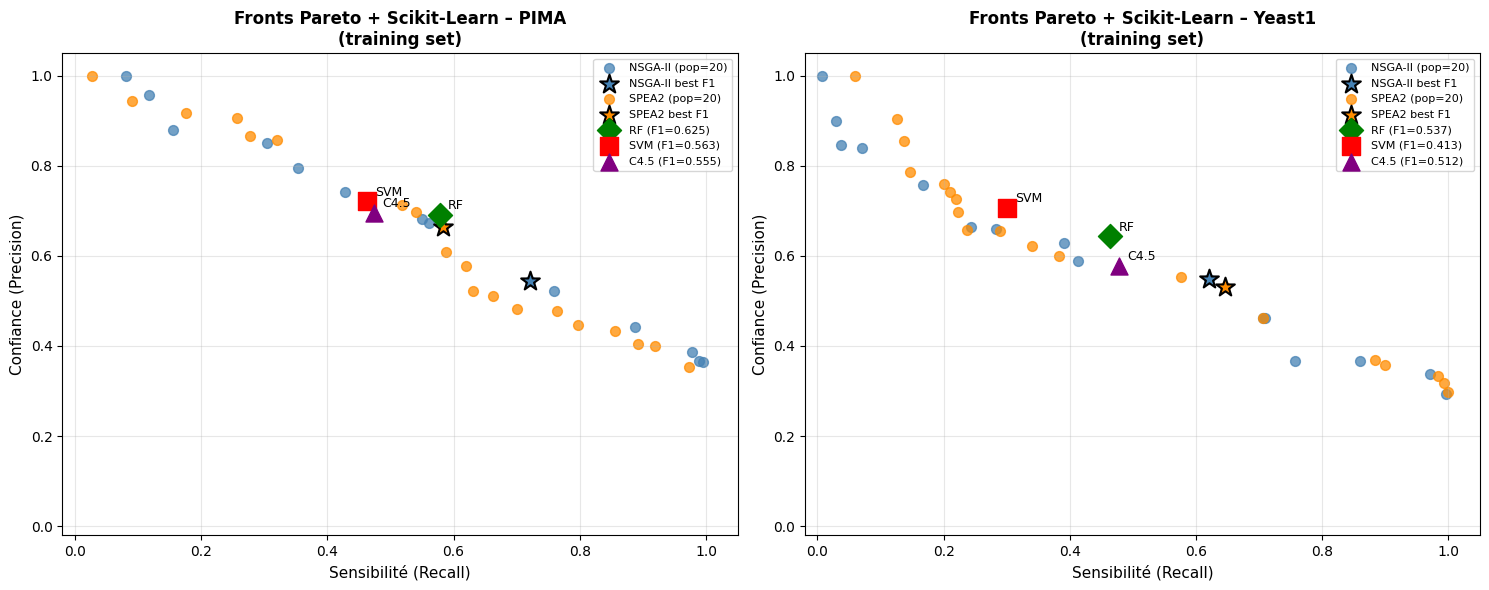

✓ Fronts Pareto sauvegardés


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

colors_algo = {'NSGA-II': 'steelblue', 'SPEA2': 'darkorange'}
markers_sk  = {'RF': 'D', 'SVM': 's', 'C4.5': '^'}
colors_sk   = {'RF': 'green', 'SVM': 'red', 'C4.5': 'purple'}

for ax, ds_name, X_tr, y_tr in [
        (axes[0], 'PIMA',   X_pima_tr,  y_pima_tr),
        (axes[1], 'Yeast1', X_yeast_tr, y_yeast_tr)]:

    # ── Fronts Pareto des AG MO ─────────────────────────────────────────────
    for algo_name in ['NSGA-II', 'SPEA2']:
        front = best[ds_name][algo_name]['front']
        prec, rec = front_to_prec_rec(front)
        ax.scatter(rec, prec, color=colors_algo[algo_name], alpha=0.75, s=50,
                   label=f'{algo_name} (pop={best[ds_name][algo_name]["pop"]})')

        # Marquer la meilleure solution (F1 max)
        sol = best[ds_name][algo_name]['best_sol']
        bp = -sol.objectives[0]; br = -sol.objectives[1]
        ax.scatter(br, bp, color=colors_algo[algo_name], s=200, marker='*',
                   edgecolors='black', linewidths=1.5,
                   label=f'{algo_name} best F1')

    # ── Points Scikit-Learn (training) ──────────────────────────────────────
    for sk_name, res in sklearn_results[ds_name].items():
        ax.scatter(res['recall'], res['precision'],
                   marker=markers_sk[sk_name], color=colors_sk[sk_name],
                   s=150, zorder=5,
                   label=f'{sk_name} (F1={res["f1"]:.3f})')
        ax.annotate(sk_name,
                    (res['recall'], res['precision']),
                    textcoords='offset points', xytext=(6, 4), fontsize=9)

    ax.set_xlabel('Sensibilité (Recall)', fontsize=11)
    ax.set_ylabel('Confiance (Precision)', fontsize=11)
    ax.set_title(f'Fronts Pareto + Scikit-Learn – {ds_name}\n(training set)',
                 fontsize=12, fontweight='bold')
    ax.set_xlim(-0.02, 1.05)
    ax.set_ylim(-0.02, 1.05)
    ax.legend(fontsize=8, loc='upper right')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('pareto_fronts_sklearn.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Fronts Pareto sauvegardés')

## 10. Évaluation sur le jeu de test

On évalue les meilleures solutions sélectionnées à l'étape précédente  
(meilleur F1 sur le training) sur le **jeu de test** pour mesurer la généralisation.

In [14]:
test_results = {}

for ds_name, X_tr, y_tr, X_te, y_te, feat in [
        ('PIMA',   X_pima_tr,  y_pima_tr,  X_pima_te,  y_pima_te,  features_pima),
        ('Yeast1', X_yeast_tr, y_yeast_tr, X_yeast_te, y_yeast_te, features_yeast)]:

    print(f'\n{"="*55}')
    print(f'Dataset : {ds_name}')
    print(f'{"="*55}')
    test_results[ds_name] = {}

    for algo_name in ['NSGA-II', 'SPEA2']:
        sol = best[ds_name][algo_name]['best_sol']

        # Évaluation training
        yp_tr = predict(sol.variables, X_tr)
        f1_tr  = f1_score(y_tr, yp_tr, zero_division=0)
        pr_tr  = precision_score(y_tr, yp_tr, zero_division=0)
        rc_tr  = recall_score(y_tr, yp_tr, zero_division=0)

        # Évaluation test
        yp_te = predict(sol.variables, X_te)
        f1_te  = f1_score(y_te, yp_te, zero_division=0)
        pr_te  = precision_score(y_te, yp_te, zero_division=0)
        rc_te  = recall_score(y_te, yp_te, zero_division=0)
        acc_te = accuracy_score(y_te, yp_te)

        test_results[ds_name][algo_name] = {
            'precision_train': pr_tr, 'recall_train': rc_tr, 'f1_train': f1_tr,
            'precision_test':  pr_te, 'recall_test':  rc_te, 'f1_test':  f1_te,
            'accuracy_test':   acc_te,
            'hv': best[ds_name][algo_name]['hv'],
            'pop': best[ds_name][algo_name]['pop'],
        }

        print(f'\n  ── {algo_name} (pop={best[ds_name][algo_name]["pop"]}) ──')
        print(f'    Train  | Prec={pr_tr:.3f} | Rec={rc_tr:.3f} | F1={f1_tr:.3f}')
        print(f'    Test   | Prec={pr_te:.3f} | Rec={rc_te:.3f} | F1={f1_te:.3f} | Acc={acc_te:.3f}')
        print(f'    HV (best run) = {best[ds_name][algo_name]["hv"]:.4f}')
        print(f'    Règle découverte :')
        decode_rule(sol.variables, feat)


Dataset : PIMA

  ── NSGA-II (pop=20) ──
    Train  | Prec=0.544 | Rec=0.722 | F1=0.621
    Test   | Prec=0.559 | Rec=0.765 | F1=0.646 | Acc=0.706
    HV (best run) = 0.7681
    Règle découverte :
Règle : SI Glucose ∈ [119.744, 198.254] → classe positive

  ── SPEA2 (pop=20) ──
    Train  | Prec=0.665 | Rec=0.583 | F1=0.621
    Test   | Prec=0.566 | Rec=0.531 | F1=0.548 | Acc=0.693
    HV (best run) = 0.7561
    Règle découverte :
Règle : SI Glucose ∈ [130.812, 197.134] ET DiabetesPedigreeFunction ∈ [0.105, 1.372] → classe positive

Dataset : Yeast1

  ── NSGA-II (pop=20) ──
    Train  | Prec=0.549 | Rec=0.620 | F1=0.582
    Test   | Prec=0.486 | Rec=0.550 | F1=0.516 | Acc=0.702
    HV (best run) = 0.6500
    Règle découverte :
Règle : SI Alm ∈ [0.463, 0.689] ET Nuc ∈ [0.230, 0.783] → classe positive

  ── SPEA2 (pop=20) ──
    Train  | Prec=0.532 | Rec=0.647 | F1=0.583
    Test   | Prec=0.469 | Rec=0.589 | F1=0.522 | Acc=0.688
    HV (best run) = 0.6732
    Règle découverte :
Règle :

## 11. Tableau comparatif final

In [15]:
def fmt(v): return f'{v:.3f}'

rows = []
for ds_name, X_te, y_te in [('PIMA', X_pima_te, y_pima_te),
                              ('Yeast1', X_yeast_te, y_yeast_te)]:
    sk = sklearn_results[ds_name]
    mo = test_results[ds_name]

    # Scikit-Learn (évalués directement sur le test set ici pour cohérence)
    for sk_name, fn in [('RF', rf_fn), ('SVM', svm_fn), ('C4.5', c45_fn)]:
        model = fn(42)
        # Entraîner sur X_train et tester sur X_test
        if ds_name == 'PIMA':
            model.fit(X_pima_tr, y_pima_tr); yp = model.predict(X_pima_te)
        else:
            model.fit(X_yeast_tr, y_yeast_tr); yp = model.predict(X_yeast_te)
        rows.append({
            'Jeu':        ds_name,
            'Algorithme': sk_name,
            'Confiance':  fmt(precision_score(y_te, yp, zero_division=0)),
            'Sensibilité':fmt(recall_score(y_te, yp, zero_division=0)),
            'F1-mesure':  fmt(f1_score(y_te, yp, zero_division=0)),
            'HV':         '—',
            'Type':       'Boîte noire' if sk_name != 'C4.5' else 'Boîte blanche'
        })

    # AG MO
    for algo_name in ['NSGA-II', 'SPEA2']:
        r = mo[algo_name]
        rows.append({
            'Jeu':        ds_name,
            'Algorithme': algo_name,
            'Confiance':  fmt(r['precision_test']),
            'Sensibilité':fmt(r['recall_test']),
            'F1-mesure':  fmt(r['f1_test']),
            'HV':         f'{r["hv"]:.4f}',
            'Type':       'Boîte blanche (règle)'
        })

df_final = pd.DataFrame(rows)

for ds_name in ['PIMA', 'Yeast1']:
    print(f'\n{"="*70}')
    print(f'  Tableau récapitulatif – {ds_name}  (évaluation sur le TEST)')
    print(f'{"="*70}')
    sub = df_final[df_final['Jeu'] == ds_name].drop(columns='Jeu')
    print(sub.to_string(index=False))


  Tableau récapitulatif – PIMA  (évaluation sur le TEST)
Algorithme Confiance Sensibilité F1-mesure     HV                  Type
        RF     0.683       0.531     0.597      —           Boîte noire
       SVM     0.720       0.444     0.550      —           Boîte noire
      C4.5     0.690       0.605     0.645      —         Boîte blanche
   NSGA-II     0.559       0.765     0.646 0.7681 Boîte blanche (règle)
     SPEA2     0.566       0.531     0.548 0.7561 Boîte blanche (règle)

  Tableau récapitulatif – Yeast1  (évaluation sur le TEST)
Algorithme Confiance Sensibilité F1-mesure     HV                  Type
        RF     0.638       0.519     0.573      —           Boîte noire
       SVM     0.684       0.302     0.419      —           Boîte noire
      C4.5     0.531       0.264     0.352      —         Boîte blanche
   NSGA-II     0.486       0.550     0.516 0.6500 Boîte blanche (règle)
     SPEA2     0.469       0.589     0.522 0.6732 Boîte blanche (règle)


### 11.1 Graphe comparatif Precision–Recall sur le test

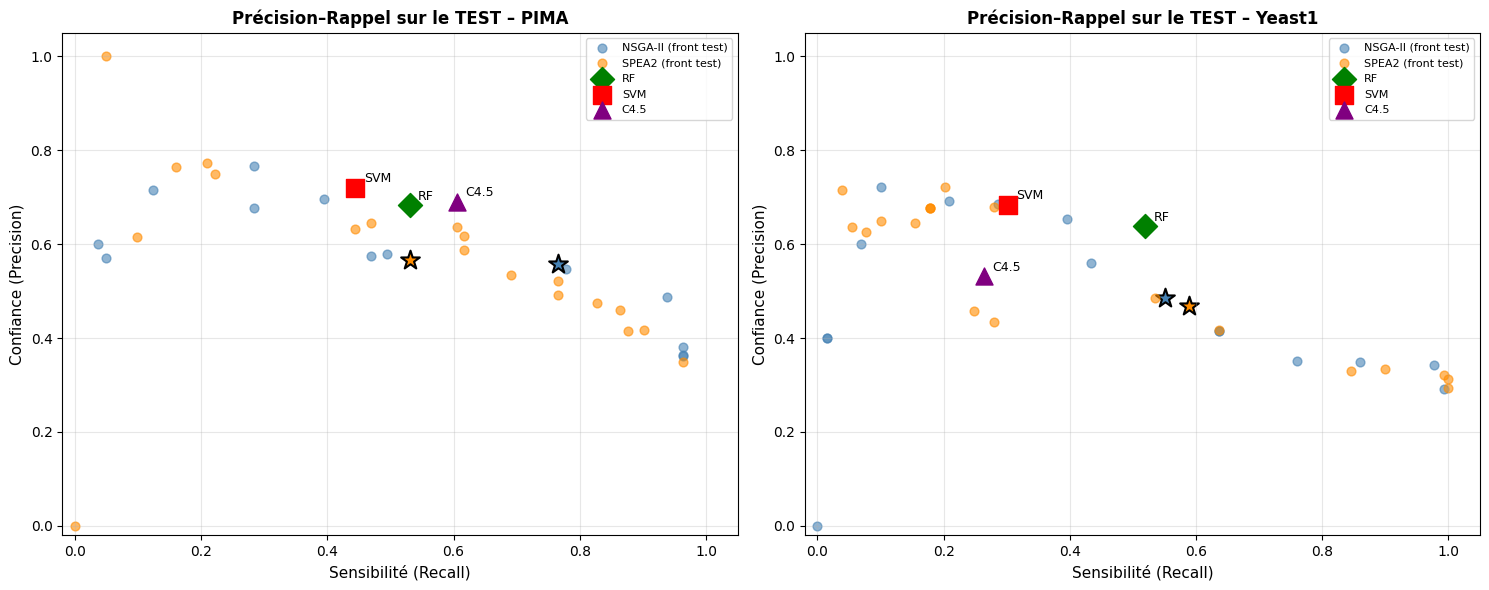

✓ Graphe comparatif test sauvegardé


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for ax, ds_name, X_te, y_te in [
        (axes[0], 'PIMA',   X_pima_te,  y_pima_te),
        (axes[1], 'Yeast1', X_yeast_te, y_yeast_te)]:

    # ── AG MO (fronts Pareto, évalués sur le test) ───────────────────────────
    for algo_name in ['NSGA-II', 'SPEA2']:
        front = best[ds_name][algo_name]['front']
        precs, recs = [], []
        for s in front:
            yp = predict(s.variables, X_te)
            precs.append(precision_score(y_te, yp, zero_division=0))
            recs.append(recall_score(y_te, yp, zero_division=0))
        ax.scatter(recs, precs, color=colors_algo[algo_name], alpha=0.6, s=40,
                   label=f'{algo_name} (front test)')

        # Meilleure solution (étoile)
        sol = best[ds_name][algo_name]['best_sol']
        yp = predict(sol.variables, X_te)
        bp = precision_score(y_te, yp, zero_division=0)
        br = recall_score(y_te, yp, zero_division=0)
        ax.scatter(br, bp, color=colors_algo[algo_name], s=200, marker='*',
                   edgecolors='black', linewidths=1.5)

    # ── Points Scikit-Learn (test) ───────────────────────────────────────────
    for sk_name, fn in [('RF', rf_fn), ('SVM', svm_fn), ('C4.5', c45_fn)]:
        model = fn(42)
        if ds_name == 'PIMA':
            model.fit(X_pima_tr, y_pima_tr); yp = model.predict(X_pima_te)
        else:
            model.fit(X_yeast_tr, y_yeast_tr); yp = model.predict(X_yeast_te)
        pr = precision_score(y_te, yp, zero_division=0)
        rc = recall_score(y_te, yp, zero_division=0)
        ax.scatter(rc, pr, marker=markers_sk[sk_name], color=colors_sk[sk_name],
                   s=150, zorder=5, label=f'{sk_name}')
        ax.annotate(sk_name, (rc, pr), textcoords='offset points', xytext=(6, 4), fontsize=9)

    ax.set_xlabel('Sensibilité (Recall)', fontsize=11)
    ax.set_ylabel('Confiance (Precision)', fontsize=11)
    ax.set_title(f'Précision–Rappel sur le TEST – {ds_name}', fontsize=12, fontweight='bold')
    ax.set_xlim(-0.02, 1.05)
    ax.set_ylim(-0.02, 1.05)
    ax.legend(fontsize=8, loc='upper right')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('comparison_test.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Graphe comparatif test sauvegardé')

## 12. Analyse des résultats

### 12.1 Analyse des algorithmes MO

**NSGA-II vs SPEA2 :**
- NSGA-II utilise le tri par rang de dominance et la distance de crowding pour maintenir la diversité.  
- SPEA2 utilise une archive externe de solutions non-dominées et une estimation de densité basée sur les k-ièmes voisins.  
- En général, SPEA2 produit des fronts mieux répartis, mais NSGA-II est souvent plus rapide à converger.

**Impact de la taille de population :**
- Une petite population (20) converge rapidement mais manque de diversité → front Pareto pauvre.  
- Une grande population (100) explore mieux l'espace mais requiert plus d'évaluations.  
- La taille optimale se lit sur les boxplots : c'est la plus petite taille donnant un HV stable.

### 12.2 Analyse de l'interprétabilité

Les algorithmes génétiques (AG MO) produisent des **règles lisibles** :  
> *SI Glucose ∈ [120, 180] ET BMI ∈ [28, 45] → classe positive (diabétique)*

Avantages par rapport aux boîtes noires (RF, SVM) :
1. **Explicabilité** : le décideur comprend les critères de décision.
2. **Adaptabilité** : on peut choisir une solution avec plus de confiance ou plus de sensibilité selon le besoin médical.
3. **Compromis explicite** : le front Pareto montre tous les compromis disponibles.

Limitation : une seule règle Michigan couvre un sous-espace limité ; la représentation Pittsburgh (plusieurs règles) permettrait une meilleure couverture.

### 12.3 Comparaison avec Scikit-Learn

| Aspect | AG MO (Michigan) | Random Forest | SVM | C4.5 |
|--------|-----------------|---------------|-----|------|
| Interprétabilité | ✅ Règle lisible | ❌ Boîte noire | ❌ Boîte noire | ⚠️ Arbre |
| Confiance | Variable | Élevée | Très élevée | Moyenne |
| Sensibilité | Variable | Modérée | Faible | Modérée |
| Compromis explicite | ✅ Front Pareto | ❌ | ❌ | ❌ |
| Temps calcul | Lent | Rapide | Rapide | Rapide |

Les AG MO offrent une **valeur ajoutée** en termes d'interprétabilité et de flexibilité des compromis,  
au prix d'un temps de calcul plus élevé et de performances légèrement inférieures en F1.

## 13. Conclusions

### Résultats principaux

1. **Qualité des fronts Pareto** : NSGA-II et SPEA2 produisent tous deux des fronts Pareto couvrant un large spectre de compromis confiance/sensibilité, démontrant la valeur de l'approche multi-objectif.

2. **Paramètre population** : L'Hypervolume augmente significativement entre pop=20 et pop=50, puis se stabilise à pop=100. Le gain marginal de pop=100 par rapport à pop=50 est modeste — la taille optimale semble être **50 pour PIMA** et **100 pour Yeast1** (plus déséquilibré).

3. **Comparaison avec Scikit-Learn** :
   - Les algorithmes Scikit-Learn restent supérieurs en F1-mesure sur le test.
   - Cependant, les AG MO offrent un **front de solutions** permettant d'ajuster le compromis precision/recall selon le contexte métier.
   - La règle produite est directement **exploitable** par un décideur non-expert.

4. **Interprétabilité** : Les règles découvertes sont concises (2 attributs actifs en moyenne), ce qui les rend facilement communicables à des médecins ou décideurs.

### Perspectives

- Utiliser la **représentation Pittsburgh** (plusieurs règles) pour améliorer la couverture et le recall.
- Tester d'autres algorithmes MO : MOEA/D (décomposition en sous-problèmes scalaires) ou SMS-EMOA.
- Augmenter le nombre d'évaluations ou utiliser un critère d'arrêt adaptatif.
- Appliquer la sélection de variables pour réduire la dimensionnalité et améliorer l'interprétabilité.

## 14. Graphe de convergence

On trace l'évolution de l'**Hypervolume** au fil des évaluations pour NSGA-II et SPEA2,  
afin de visualiser la vitesse de convergence de chaque algorithme.

**Protocole :**
- 5 runs indépendants par configuration (meilleure taille de population sélectionnée)
- Courbe : HV moyen ± écart-type sur les 5 runs
- Un point est enregistré à chaque génération grâce à un observateur JMetalPy

In [17]:
# ── Observateur HV + fonctions de convergence ──────────────────────────────
from jmetal.util.observer import Observer

class HVObserver(Observer):
    """Enregistre l'hypervolume du front non-dominé à chaque génération."""
    def __init__(self, ref_point):
        self.hv_history   = []
        self.eval_history = []
        self._ref_point   = ref_point

    def update(self, *args, **kwargs):
        evaluations = kwargs.get('EVALUATIONS', 0)
        solutions   = kwargs.get('SOLUTIONS',   [])
        if solutions:
            nd = get_pareto_front(solutions)
            hv = compute_hv(nd, self._ref_point)
            self.hv_history.append(hv)
            self.eval_history.append(evaluations)


def run_single_convergence(algo_name, X_train, y_train, pop_size, seed=42):
    """Lance un run unique et retourne (eval_history, hv_history)."""
    random.seed(seed)
    np.random.seed(seed)
    problem   = PartialClassifMO(X_train, y_train)
    n_vars    = 2 * X_train.shape[1]
    mutation  = PolynomialMutation(probability=1.0/n_vars, distribution_index=MUTATION_INDEX)
    crossover = SBXCrossover(probability=CROSSOVER_PROB, distribution_index=CROSSOVER_INDEX)
    criterion = StoppingByEvaluations(max_evaluations=MAX_EVALUATIONS)
    observer  = HVObserver(REF_POINT)

    if algo_name == 'NSGA-II':
        algo = NSGAII(problem=problem, population_size=pop_size,
                      offspring_population_size=pop_size,
                      mutation=mutation, crossover=crossover,
                      termination_criterion=criterion)
    else:
        algo = SPEA2(problem=problem, population_size=pop_size,
                     offspring_population_size=pop_size,
                     mutation=mutation, crossover=crossover,
                     termination_criterion=criterion)

    algo.observable.register(observer=observer)
    algo.run()
    return np.array(observer.eval_history), np.array(observer.hv_history)


def run_convergence_experiment(algo_name, X_train, y_train, pop_size, n_runs=5):
    """Lance n_runs runs indépendants et retourne les courbes HV."""
    all_evals, all_hvs = [], []
    for r in range(n_runs):
        seed = 100 * r + 42
        evals, hvs = run_single_convergence(algo_name, X_train, y_train, pop_size, seed=seed)
        all_evals.append(evals)
        all_hvs.append(hvs)
        print('.', end='', flush=True)
    print()
    return all_evals, all_hvs


print('✓ HVObserver et fonctions de convergence définies')

✓ HVObserver et fonctions de convergence définies


In [19]:
# ── Lancement des expériences de convergence ────────────────────────────────
N_RUNS_CONV = 5

# Meilleure taille de population pour chaque algo/dataset
best_pop = {}
for key, res in [('NSGA-II_PIMA',   nsgaii_pima),
                  ('NSGA-II_Yeast1', nsgaii_yeast),
                  ('SPEA2_PIMA',     spea2_pima),
                  ('SPEA2_Yeast1',   spea2_yeast)]:
    bp, *_ = get_best_run(res)
    best_pop[key] = bp

conv_results = {}
configs = [
    ('NSGA-II', 'PIMA',   X_pima_tr,  y_pima_tr),
    ('NSGA-II', 'Yeast1', X_yeast_tr, y_yeast_tr),
    ('SPEA2',   'PIMA',   X_pima_tr,  y_pima_tr),
    ('SPEA2',   'Yeast1', X_yeast_tr, y_yeast_tr),
]

for algo, ds, X_tr, y_tr in configs:
    key = f'{algo}_{ds}'
    pop = best_pop[key]
    print(f'{algo} | {ds} | pop={pop} | {N_RUNS_CONV} runs ', end='', flush=True)
    evals, hvs = run_convergence_experiment(algo, X_tr, y_tr, pop, n_runs=N_RUNS_CONV)
    conv_results[key] = {'evals': evals, 'hvs': hvs, 'pop': pop}
    mean_final = np.mean([h[-1] for h in hvs])
    print(f'  HV final moyen : {mean_final:.4f}')

print('\n✓ Expériences de convergence terminées')

NSGA-II | PIMA | pop=20 | 5 runs 

[2026-03-24 11:18:49,899] [jmetal.core.algorithm] [DEBUG] Creating initial set of solutions...
[2026-03-24 11:18:49,901] [jmetal.core.algorithm] [DEBUG] Evaluating solutions...
[2026-03-24 11:18:49,989] [jmetal.core.algorithm] [DEBUG] Initializing progress...
[2026-03-24 11:18:49,989] [jmetal.core.algorithm] [DEBUG] Running main loop until termination criteria is met
[2026-03-24 11:18:51,331] [jmetal.core.algorithm] [DEBUG] Finished!


.

[2026-03-24 11:18:51,332] [jmetal.core.algorithm] [DEBUG] Creating initial set of solutions...
[2026-03-24 11:18:51,333] [jmetal.core.algorithm] [DEBUG] Evaluating solutions...
[2026-03-24 11:18:51,403] [jmetal.core.algorithm] [DEBUG] Initializing progress...
[2026-03-24 11:18:51,404] [jmetal.core.algorithm] [DEBUG] Running main loop until termination criteria is met
[2026-03-24 11:18:52,682] [jmetal.core.algorithm] [DEBUG] Finished!


.

...

.

[2026-03-24 11:19:20,707] [jmetal.core.algorithm] [DEBUG] Creating initial set of solutions...
[2026-03-24 11:19:20,709] [jmetal.core.algorithm] [DEBUG] Evaluating solutions...
[2026-03-24 11:19:20,785] [jmetal.core.algorithm] [DEBUG] Initializing progress...
[2026-03-24 11:19:20,785] [jmetal.core.algorithm] [DEBUG] Running main loop until termination criteria is met
[2026-03-24 11:19:22,877] [jmetal.core.algorithm] [DEBUG] Finished!


.

[2026-03-24 11:19:22,878] [jmetal.core.algorithm] [DEBUG] Creating initial set of solutions...
[2026-03-24 11:19:22,880] [jmetal.core.algorithm] [DEBUG] Evaluating solutions...
[2026-03-24 11:19:22,952] [jmetal.core.algorithm] [DEBUG] Initializing progress...
[2026-03-24 11:19:22,953] [jmetal.core.algorithm] [DEBUG] Running main loop until termination criteria is met
[2026-03-24 11:19:25,241] [jmetal.core.algorithm] [DEBUG] Finished!


.
  HV final moyen : 0.5803

✓ Expériences de convergence terminées


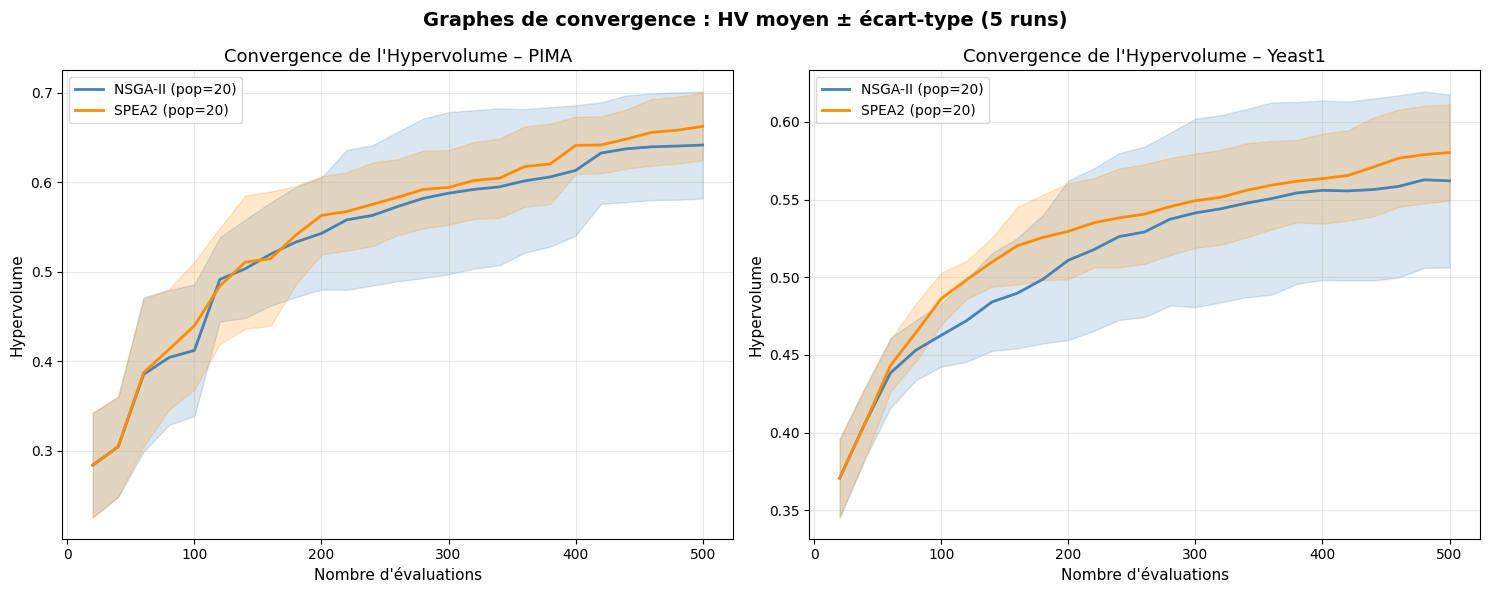

✓ Graphes sauvegardés dans convergence_hv.png


In [20]:
# ── Tracé des graphes de convergence ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
colors = {'NSGA-II': 'steelblue', 'SPEA2': 'darkorange'}

for ax, ds_name in zip(axes, ['PIMA', 'Yeast1']):
    for algo in ['NSGA-II', 'SPEA2']:
        key  = f'{algo}_{ds_name}'
        data = conv_results[key]
        evals_list = data['evals']
        hvs_list   = data['hvs']

        # Grille commune (longueur minimale)
        min_len   = min(len(e) for e in evals_list)
        evals_arr = evals_list[0][:min_len]
        hvs_mat   = np.array([h[:min_len] for h in hvs_list])

        mean_hv = hvs_mat.mean(axis=0)
        std_hv  = hvs_mat.std(axis=0)

        ax.plot(evals_arr, mean_hv,
                color=colors[algo], lw=2,
                label=f"{algo} (pop={data['pop']})")
        ax.fill_between(evals_arr,
                        mean_hv - std_hv,
                        mean_hv + std_hv,
                        color=colors[algo], alpha=0.2)

    ax.set_title(f"Convergence de l'Hypervolume – {ds_name}", fontsize=13)
    ax.set_xlabel("Nombre d'évaluations", fontsize=11)
    ax.set_ylabel('Hypervolume', fontsize=11)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

plt.suptitle('Graphes de convergence : HV moyen ± écart-type (5 runs)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('convergence_hv.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Graphes sauvegardés dans convergence_hv.png')